In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
data = pd.read_csv("./RegData.csv")

In [16]:
data.describe()

,StID,SAT,GPA
count,84.000000,84.000000,84.000000
mean,149.619048,1345.273810,3.330238
std,29.499808,104.530661,0.271617
min,101.000000,1134.000000,2.400000
25%,122.750000,1272.000000,3.190000
50%,149.500000,1346.000000,3.380000
75%,175.500000,1434.000000,3.502500
max,198.000000,1550.000000,3.810000


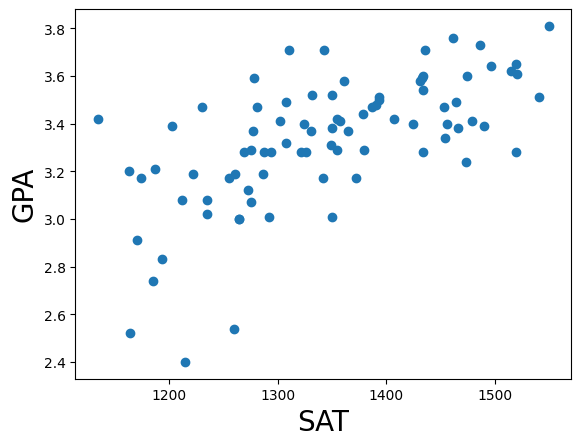

In [17]:
y = data ['GPA']
x = data ['SAT']
plt.scatter(x,y)
plt.xlabel ('SAT', fontsize = 20)
plt.ylabel ('GPA', fontsize = 20)
plt.show()

In [18]:
data[['SAT','GPA']].corr()

,SAT,GPA
SAT,1.000000,0.637184
GPA,0.637184,1.000000


In [19]:
import seaborn as sns

<Axes: >

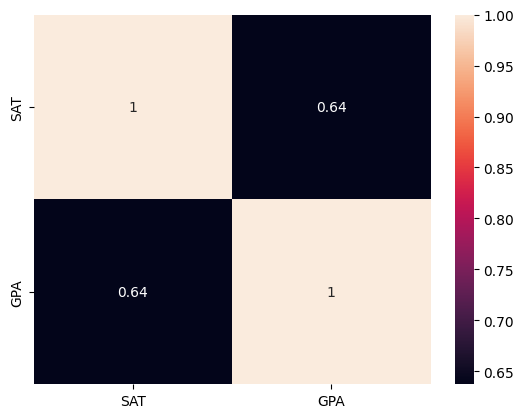

In [20]:
sns.heatmap(data[['SAT', 'GPA']].corr(),annot = True)

In [21]:
from scipy.stats import linregress

In [22]:
slope, intercept, r_value, p_value, std_err = linregress(x,y)

In [23]:
print ("Slope:", slope)
print("Intercept", intercept)

Slope: 0.001655688050092813
Intercept 1.1028843247066882


In [24]:
y1 = slope*x + intercept

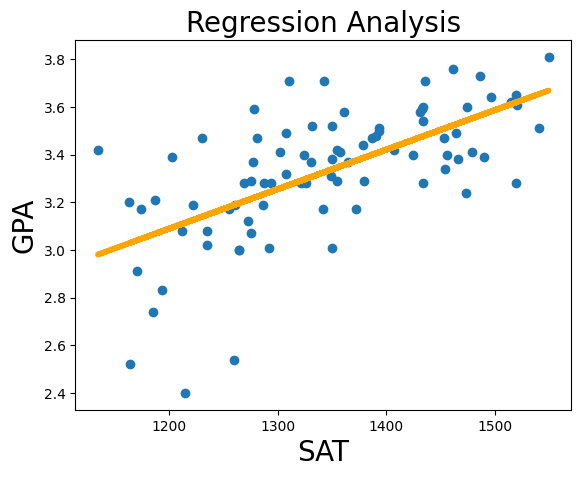

In [25]:
plt.scatter(x,y)

fig  = plt.plot(x,y1, lw=4, c='orange', label = 'regression line')
plt.title("Regression Analysis", fontsize = 20)
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()

FIND THE PREDICTED VALUE OF UNSEEN DATA

In [26]:
givenSAT = 1450
predGPA = slope * givenSAT + intercept
predGPA

np.float64(3.503631997341267)

ACTUAL VS PREDICTED

In [27]:
df_p = pd.DataFrame({"ActualGPA":y, "PredictedGPA":y1})
df_p.head()

,ActualGPA,PredictedGPA
0,3.42,3.346342
1,3.48,3.405946
2,2.91,3.040039
3,3.41,3.349653
4,3.28,3.298327


<Axes: >

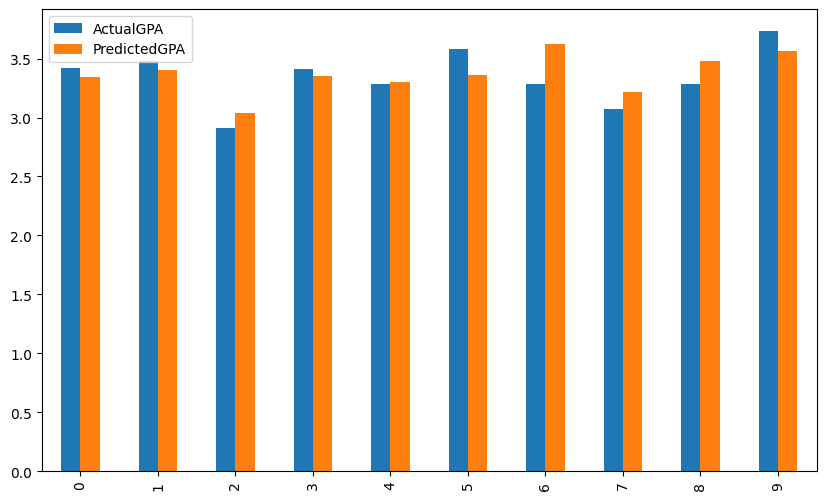

In [28]:
df_p.head(10).plot(kind="bar", figsize=(10,6))

In [29]:
df_a_p = pd.DataFrame({**data,"PredictedGPA":y1})
df_a_p.head()

,StID,SAT,GPA,PredictedGPA
0,101,1355,3.42,3.346342
1,102,1391,3.48,3.405946
2,103,1170,2.91,3.040039
3,104,1357,3.41,3.349653
4,105,1326,3.28,3.298327


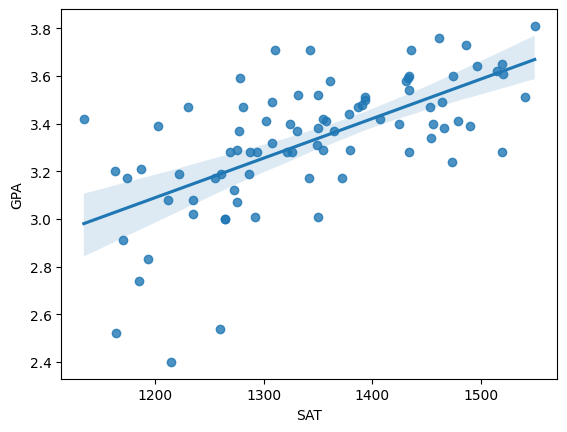

In [30]:
import seaborn as sns
p = sns.regplot(data=data, x=data.SAT, y=data.GPA)

<Axes: xlabel='SAT', ylabel='GPA'>

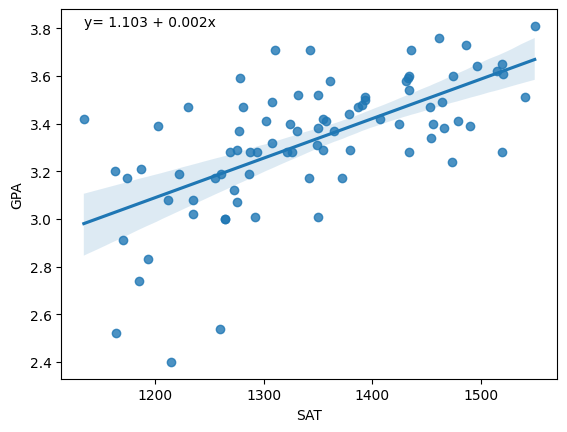

In [31]:
#add regression equvation to plot
plt.text(min(data.SAT), max(data.GPA), 'y= ' + str(round(intercept,3)) + ' + ' + str(round(slope,3)) + 'x')
sns.regplot(data=data, x=data.SAT, y=data.GPA)

In [32]:
#split data
from sklearn.model_selection import train_test_split

In [33]:
x = data.SAT
y = data.GPA

# split data
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

# reshape for sklearn
X_train = X_train.to_numpy().reshape(-1, 1)
X_test = X_test.to_numpy().reshape(-1, 1)

In [34]:
from sklearn.linear_model import LinearRegression
rgsr= LinearRegression()

In [35]:
#fit a model
model =rgsr.fit(X_train,y_train)

In [36]:
#make prediction on test set
y_pred = model.predict(X_test)

In [37]:
y= pd.DataFrame({'Original': y_test , 'Predicted':y_pred})
y.head()

,Original,Predicted
10,3.01,3.270437
67,3.40,3.527507
59,2.52,3.069796
33,3.71,3.298652
83,3.44,3.406809


Evaluation Indicators

In [38]:
from sklearn import metrics

In [39]:
print ('Evaluation indicators')
print ("MAE:\t", metrics.mean_absolute_error(y_test,y_pred) )
print ("MSE:\t", metrics.mean_squared_error(y_test,y_pred) )
print ("RMSE:\t", metrics.mean_squared_error(y_test,y_pred)**(0.5))
print ("R-Squared", metrics.r2_score(y_test,y_pred) )

Evaluation indicators
MAE:	 0.2054834292112158
MSE:	 0.08052728657188303
RMSE:	 0.28377330137256224
R-Squared 0.3346446677333793


Applying Gradient Decent

In [40]:
import numpy as np

In [41]:
#1. Initialize parameters
b0 = 0.0
b1 = 0.0
learning_rate = 0.00000001 #small alpha because SAT scores are large
epochs = 1000 # Number of iterations
n = float (len(X_train)) # Number of elements in X_train

In [42]:
#Ensure X_train and y_train are flattened for calculation
x_vals = X_train.flatten()
y_vals = y_train.to_numpy()

In [43]:
#2 The Gradient Descent Loop
for i in range (epochs):
  # Current Prediction
    y_current = b1 * x_vals +b0

    #Calculate Gradient (Partial dERIVATIES)
    #D_b1 = -2/n * sum(x * (y_actual - y_ predicted))
    #D_b0 = -2/n * sum(y_actual -y_predicted)
    D_b1 =(-2/n) * sum(x_vals * (y_vals - y_current))
    D_b0 =(-2/n) * sum(y_vals - y_current)

    #Update Parameters

    b1= b1 - learning_rate * D_b1
    b0= b0 - learning_rate * D_b0

print(f"Final intercept (b0): {b0}")
print(f"Final Slope (b1): {b1}")

Final intercept (b0): 1.9683432519427444e-06
Final Slope (b1): 0.00248961468948327


In [44]:
#3 Make pReduction for test set
y_pred_gd = b1* X_test.flatten() +b0

In [45]:
from sklearn import metrics

print ('---Gradient Descent Evaluation---')
print ("MAE:\t", metrics.mean_absolute_error(y_test,y_pred_gd) )
print ("MSE:\t", metrics.mean_squared_error(y_test,y_pred_gd) )
print ("RMSE:\t", metrics.mean_squared_error(y_test,y_pred_gd)**(0.5))
print ("R-Squared", metrics.r2_score(y_test,y_pred_gd) )

---Gradient Descent Evaluation---
MAE:	 0.2310720513521187
MSE:	 0.08653757452976028
RMSE:	 0.2941726950785206
R-Squared 0.28498476596006195
